TASK 1 : DATA IMMERSION AND WRANGLING

Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Loading

The dataset is loaded into a Pandas DataFrame for analysis.  
Initial inspection of the dataset helps understand its structure, including the number of rows and columns.

In [ ]:
# Load dataset
df = pd.read_csv("/content/online_retail.csv")
print("Shape:", df.shape)
df.head()

Shape: (340479, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Standardizing Column Names

Column names are cleaned by removing extra spaces and converting them to lowercase.  
This ensures consistency and prevents errors during data processing.

In [ ]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')


### Data Exploration

In this step, we explore the dataset structure and summary statistics.  
- `.info()` provides data types and non-null counts  
- `.describe()` gives statistical summaries for numerical columns  

This helps identify potential data quality issues early.

In [ ]:
# Check data types
df.info()
# Statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340479 entries, 0 to 340478
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    340479 non-null  object 
 1   stockcode    340479 non-null  object 
 2   description  339292 non-null  object 
 3   quantity     340479 non-null  int64  
 4   invoicedate  340479 non-null  object 
 5   unitprice    340478 non-null  float64
 6   customerid   247817 non-null  float64
 7   country      340478 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 20.8+ MB


,quantity,unitprice,customerid
count,340479.000000,340478.000000,247817.000000
mean,9.711650,4.827007,15277.648123
std,188.820597,110.103981,1725.743088
min,-74215.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13862.000000
50%,3.000000,2.100000,15150.000000
75%,10.000000,4.130000,16809.000000
max,74215.000000,38970.000000,18287.000000


### Data Dictionary Creation

A data dictionary is created to document each variable in the dataset.  
It includes:
- Column names  
- Data types  
- Descriptions  
- Business relevance  

This step ensures clarity and aligns technical data with business understanding.

In [ ]:
import pandas as pd

# Create base data dictionary
data_dict = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values,
    "Unique Values": df.nunique().values
})

# Normalize column names (important for mapping)
data_dict["Column Name"] = data_dict["Column Name"].str.lower()

# ---------------------------
# Column Descriptions
# ---------------------------
descriptions = {
    "invoiceno": "Unique invoice number for each transaction",
    "stockcode": "Unique product/item code",
    "description": "Name/description of the product",
    "quantity": "Number of items purchased",
    "invoicedate": "Date and time of transaction",
    "unitprice": "Price per unit of product",
    "customerid": "Unique customer identifier",
    "country": "Country of the customer",

    # Engineered Features (if created)
    "order year": "Year extracted from invoice date",
    "order month": "Month extracted from invoice date",
    "order day": "Day extracted from invoice date",
    "order weekday": "Day of week of transaction",
    "total price": "Total transaction value (quantity × unit price)"
}

# ---------------------------
# Business Relevance
# ---------------------------
business_use = {
    "invoiceno": "Used to track transactions",
    "stockcode": "Used for product-level analysis",
    "description": "Helps identify product trends",
    "quantity": "Used to measure demand",
    "invoicedate": "Used for time-based analysis",
    "unitprice": "Used for pricing strategy",
    "customerid": "Used for customer segmentation",
    "country": "Used for geographical insights",

    # Engineered Features
    "order year": "Used for yearly sales trends",
    "order month": "Used for seasonal analysis",
    "order weekday": "Used for purchase pattern analysis",
    "total price": "Key revenue metric"
}

# ---------------------------
# Map descriptions & business use
# ---------------------------
data_dict["Description"] = data_dict["Column Name"].map(descriptions)
data_dict["Business Relevance"] = data_dict["Column Name"].map(business_use)

# Fill missing values
data_dict.fillna("Not Defined", inplace=True)

# Final output
print(data_dict)

   Column Name Data Type  Non-Null Count  Unique Values  \
0    invoiceno    object          340479          17363   
1    stockcode    object          340479           3835   
2  description    object          339292           3874   
3     quantity     int64          340479            556   
4  invoicedate    object          340479          15700   
5    unitprice   float64          340478           1316   
6   customerid   float64          247817           3455   
7      country    object          340478             37   

                                  Description               Business Relevance  
0  Unique invoice number for each transaction       Used to track transactions  
1                    Unique product/item code  Used for product-level analysis  
2             Name/description of the product    Helps identify product trends  
3                   Number of items purchased           Used to measure demand  
4                Date and time of transaction     Used for time

### Data Quality Assessment

The dataset is checked for common data issues such as:
- Missing values  
- Duplicate records  

Identifying these issues is critical before performing any analysis.

In [ ]:
# Missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 invoiceno          0
stockcode          0
description     1187
quantity           0
invoicedate        0
unitprice          1
customerid     92662
country            1
dtype: int64


In [ ]:
# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 2657


**Data Cleaning**

In [ ]:
print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip().str.lower()

### Data Cleaning

In this step, data inconsistencies are handled:
- Date columns are converted to proper datetime format  
- Duplicate rows are removed  
- Missing values are handled appropriately  

This ensures the dataset is accurate and reliable for analysis.

In [ ]:
df.drop_duplicates(inplace=True)

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_4443/67968268.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
print(df.columns)

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')


### Feature Engineering

New features are created from existing data to enhance analysis:
- Time-based features (year, month, day, weekday)  
- Shipping duration calculated from order and ship dates  

These features help uncover trends and improve business insights.

In [ ]:
df['invoicedate'] = pd.to_datetime(df['invoicedate'], errors='coerce')

# Drop rows where 'invoicedate' became NaT due to parsing errors
df.dropna(subset=['invoicedate'], inplace=True)

# ---------------------------
# Date-based Features
# ---------------------------
df['order year'] = df['invoicedate'].dt.year
df['order month'] = df['invoicedate'].dt.month
df['order day'] = df['invoicedate'].dt.day
df['order weekday'] = df['invoicedate'].dt.day_name()
df['order hour'] = df['invoicedate'].dt.hour
df['month name'] = df['invoicedate'].dt.month_name()
df['quarter'] = df['invoicedate'].dt.quarter

# ---------------------------
# Transaction Features
# ---------------------------
df['total price'] = df['quantity'] * df['unitprice']

# Average price per unit (safety check)
df['avg price per unit'] = df['total price'] / df['quantity']

# ---------------------------
# Customer-Level Features
# ---------------------------
# Total spending per customer
df['customer total spend'] = df.groupby('customerid')['total price'].transform('sum')

# Total number of orders per customer
df['customer total orders'] = df.groupby('customerid')['invoiceno'].transform('nunique')

# Average order value per customer
df['avg order value'] = df['customer total spend'] / df['customer total orders']

# ---------------------------
# Product-Level Features
# ---------------------------
# Total quantity sold per product
df['product total sold'] = df.groupby('stockcode')['quantity'].transform('sum')

# Total revenue per product
df['product total revenue'] = df.groupby('stockcode')['total price'].transform('sum')

# ---------------------------
# Time-based Advanced Features
# ---------------------------
# Weekend vs Weekday
df['is weekend'] = df['order weekday'].isin(['Saturday', 'Sunday']).astype(int)

### Outlier Detection

Outliers in the sales data are identified using:
- Boxplot visualization  
- Interquartile Range (IQR) method  

Detecting outliers helps understand extreme values and ensures robust analysis.

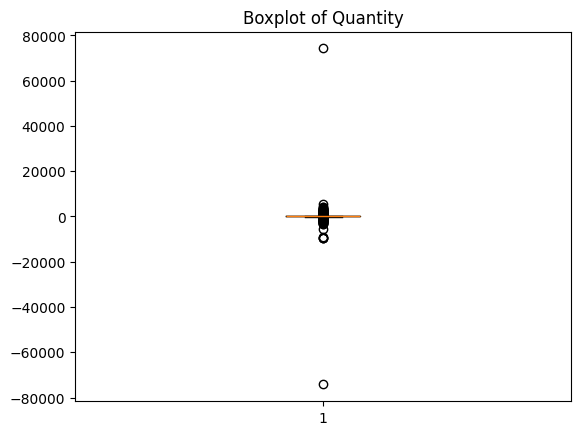

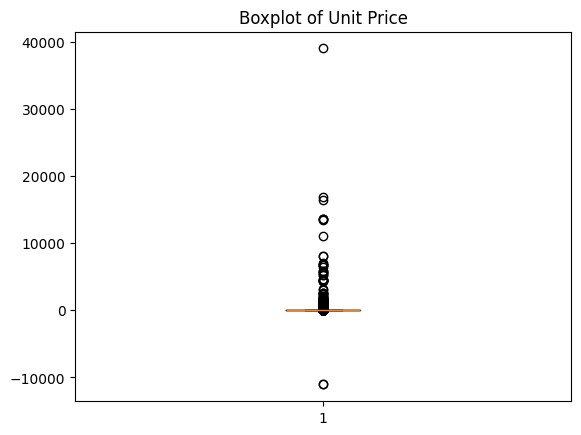

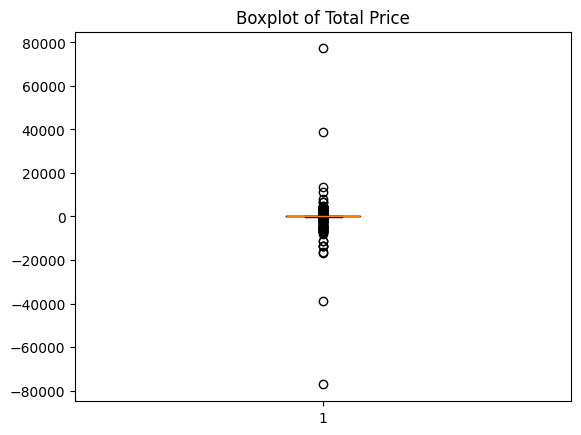

In [ ]:
import matplotlib.pyplot as plt

# Boxplot for Quantity
plt.boxplot(df['quantity'])
plt.title("Boxplot of Quantity")
plt.show()

# Boxplot for UnitPrice
plt.boxplot(df['unitprice'])
plt.title("Boxplot of Unit Price")
plt.show()

# Boxplot for Total Price
plt.boxplot(df['total price'])
plt.title("Boxplot of Total Price")
plt.show()

### Saving Cleaned Dataset

The final cleaned and transformed dataset is saved as a CSV file.  
This dataset is now ready for further analysis such as EDA and dashboarding.

In [ ]:
# Save cleaned dataset to CSV
df.to_csv("cleaned_online_retail.csv", index=False)

### Conclusion

The dataset was successfully cleaned and prepared for analysis.  
Key data quality issues were addressed, and new features were engineered to improve analytical capabilities.  
This structured dataset will be used in the next stages for exploratory data analysis and business insights.